# ASTR 19 Group Project Solution

1) Download this data set provided that lists tidal measurements in Santa Cruz for every day in January and February 2022. In your Jupyter notebook, define an oscillatory function in Python to describe the intra- and inter-day variations in the tide.

2) Using the scipy library, fit the oscillatory function to the data assuming the root mean squared experimental error on the height of the tide is 0.25 ft. Document these steps in the Jupyter notebook, and graph both the model and the data on the same plot. Label the data, provide sufficient labeling of the axes to provide clarity, and have the notebook save the figure to a PDF.

4) During the first high-tide of January 14, the tsunami from the underwater eruption of the Hunga Tonga-Hunga Ha'apai volcano reached the shores of Santa Cruz. The tsunami increased water levels near high tide by about 2ft. How large of a deviation is this tsunami, in terms of standard deviations of the distribution of normal tides from the model? Add a single 2ft outlier to the histogram of data and replot it as part of your Jupyter notebook.

### First import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize 

# Model the tides

### Read in data

First, read in the tidal data and convert days, hours, minutes to time elapsed.

In [2]:
### Read in the data

#define the file name
fname = "ASTR19_F23_group_project_data.txt"

#open the file to read
fp = open(fname,"r")

#read in all the lines
fl = fp.readlines()

#close the file
fp.close()

### Reformat the data

Need time in hours rather than d:h:m format.

In [3]:
#parse the file

#how many lines are in the file?
nlines = len(fl)

#the first 3 lines are the header
nheader = 3

#the number of valid lines
n = nlines - nheader

#create arrays for the days, hours, minutes, and tide
#add an array for the total elapsed time
days    = np.zeros(n)
hours   = np.zeros(n)
minutes = np.zeros(n)
tide    = np.zeros(n)
time    = np.zeros(n)

#loop through lines in the file
for i in range(n):
    #split the line into delimited pieces
    line = fl[i+nheader].split()
    
    #record the days
    days[i] = float(line[0])
    
    #record the hour of the day
    hours[i]   = float(line[1].split(":")[0])
    minutes[i] = float(line[1].split(":")[1])
    
    #record the tide
    tide[i] = float(line[2])
    
    
#now that we have the days, hours, minutes
#we can compute the elapsed time
hours_in_day = 24.
minutes_in_hour = 60.
time = hours_in_day*(days-1.0) + hours + minutes/minutes_in_hour

#Following the instructions,
#make an array for error on tides
#instructions say error is three inches
tide_err = np.full(tide.shape,0.25)

### Plot the data to see what it looks like

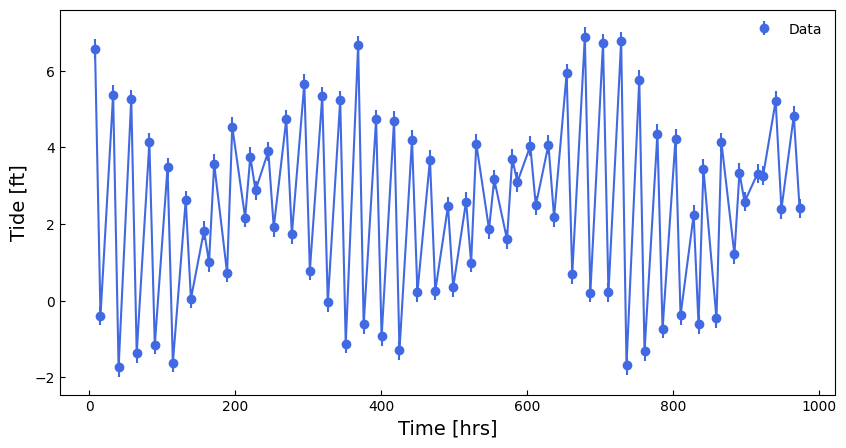

In [4]:
#create the figure and axes for a single plot
f,ax = plt.subplots(1,1,figsize=(10,5))

#plot the data
ax.errorbar(time,tide,tide_err,fmt='o',color='royalblue',label='Data')
ax.plot(time,tide,color='royalblue')

#set the tickmarks inward
ax.xaxis.set_tick_params(direction='in')
ax.yaxis.set_tick_params(direction='in')


#increase the label font size
label_font_size = 14
ax.set_xlabel('Time [hrs]',fontsize=label_font_size)
ax.set_ylabel('Tide [ft]',fontsize=label_font_size)

#add a legend
ax.legend(frameon=False)

### Define our model to fit the data

The model consists of:

1) A sinusoidal variation with a period of 24 hours and a phase of p0 hours and a mean mean_tide.

2) The sinusoidal variation has an amplitude that oscillates. On average, the tidal amplitude is mean_tidal_amplitude. The amplitdue varies on roughly two week and 28 day time scales sinusoidally, with amplitudes A1 and A2 and phases p1 and p2.

#### Find the mean tide

In [5]:
mean_tide = np.mean(tide)

#### Find the mean tidal amplitude

In [6]:
mean_tidal_amplitude = np.mean(np.abs(tide-mean_tide))

#### Define the model according to the above

In [7]:
def amplitude_model(time, A1, A2, amplitude_phase, period_scale):
    period_1 = period_scale * 14. * 24. # about two weeks
    period_2 = period_scale * 28. * 24. # about four weeks
    
    return A1*np.sin(2.0*np.pi*time/period_1-amplitude_phase) + A2*np.sin(2.0*np.pi*time/period_2-amplitude_phase) + mean_tide

In [8]:
def model_fit(time,p1,A1,A2,amplitude_phase,period_scale):
    
    #get the amplitude
    amplitude = amplitude_model(time, A1, A2, amplitude_phase, period_scale)
    
    #return the model of daily variations
    model = amplitude * np.sin(2.0*np.pi*time/24. - p1) + mean_tide
    return model

### Fit a model using scipy.optimize.curve_fit

In [9]:
#make some initial guesses
p_in = np.asarray([6.1,0.5,1.0,5.6,1.0])

#set upper and lower boundaries on the search
lower = np.zeros_like(p_in)
upper = np.full(p_in.shape,10.)

#perform the fit
params, params_cov = optimize.curve_fit(model_fit,time,tide,sigma=tide_err,p0=p_in,bounds=(lower,upper),maxfev=100000)

### Print the best fit parameters

Evaluate the model on a finer grid for nice plotting...

In [10]:
print(params)

#get an array for time
n_model = 10000
time_model = np.linspace(0,time.max(),n_model)
tide_model = model_fit(time_model,params[0],params[1],params[2],params[3],params[4])

[6.37998408 1.41141941 0.44110107 5.51732192 1.01896288]


## Plot the data and fit, save to file

The instructions say:
    
    2) Using the scipy library, fit the oscillatory function to the data assuming the root mean squared experimental error on the height of the tide is 0.5 ft. Document these steps in the Jupyter notebook, and graph both the model and the data on the same plot. Label the data, provide sufficient labeling of the axes to provide clarity, and have the notebook save the figure to a PDF.


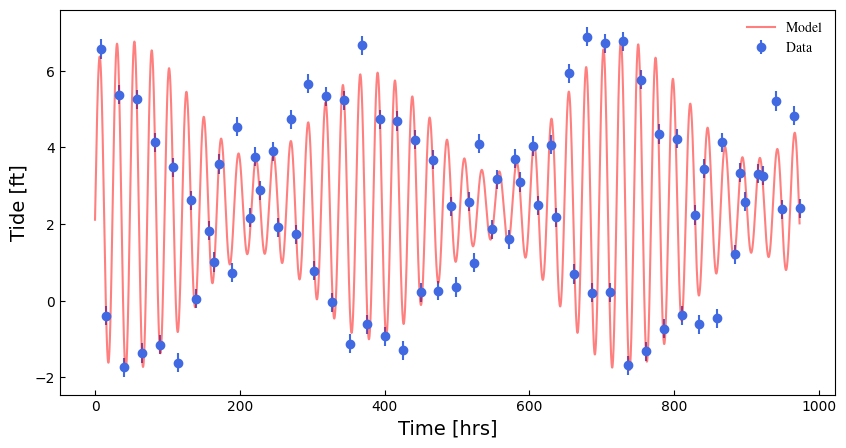

In [11]:
#create the figure and axes for a single plot
f,ax = plt.subplots(1,1,figsize=(10,5))

#change the font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

#plot the data
ax.errorbar(time,tide,tide_err,fmt='o',color='royalblue',label='Data')
#ax.plot(time,tide,color='royalblue')

#plot the model
ax.plot(time_model,tide_model,color='red',alpha=0.5,label='Model')

#set the tickmarks inward
ax.xaxis.set_tick_params(direction='in')
ax.yaxis.set_tick_params(direction='in')


#increase the label font size
label_font_size = 14
ax.set_xlabel('Time [hrs]',fontsize=label_font_size)
ax.set_ylabel('Tide [ft]',fontsize=label_font_size)

#add a legend
ax.legend(frameon=False)

#save the figure
plt.savefig('group_project_solution-fit.pdf',bbox_inches="tight",pad_inches=0,facecolor='1')

## Study the residuals

The instructions say:

    3) Next, have your notebook subtract off the best fit function from the data and plot the residuals. Assess graphically and mathematically deviations of the measured tidal data from the model. Plot a histogram of the residuals and measure the standard deviation. Is the scatter in the data larger than the assumed experimental error? Estimate the intrinsic scatter in the data after accounting for the assumed measurement error. Save the histogram as a PDF using our histogram best practices, including labeling of the data, axis labels, and "reasonable" bin widths as demonstrated in class.

### Measure the residuals

In [12]:
#evaluate the model at the measurement times
tide_model_points = np.interp(time,time_model,tide_model)

#get the residuals
residuals = tide-tide_model_points

### How big is the scatter and how does it compare to the assumed error?

In [13]:
#measured scatter
scatter_assumed = 0.25
scatter = np.std(residuals)
print(f"The scatter = {scatter} ft. This is slightly more than the assumed error of 0.25 ft.")

#intrinsic scatter 
scatter_intrinsic = (scatter**2 - scatter_assumed**2)**0.5
print(f"The intrinsic scatter is about {scatter_intrinsic} ft.")

The scatter = 0.5302365635680918 ft. This is slightly more than the assumed error of 0.25 ft.
The intrinsic scatter is about 0.46760112632937384 ft.


### Plot a histogram the residuals

In [ ]:
#create the figure and axes for a single plot
f,ax = plt.subplots(1,1,figsize=(5,5))

#change the font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

#plot the data
plt.hist(residuals,bins=15,alpha=0.5,edgecolor='0.25',label='Residuals')

#set the tickmarks inward
ax.xaxis.set_tick_params(direction='in')
ax.yaxis.set_tick_params(direction='in')


#increase the label font size
label_font_size = 14
ax.set_xlabel('Tide Model Residuals [ft]',fontsize=label_font_size)
ax.set_ylabel('Number',fontsize=label_font_size)

#add a legend
ax.legend(frameon=False)

#save the figure
plt.savefig('group_project_solution-histogram.pdf',bbox_inches="tight",pad_inches=0,facecolor='1')

## Model the outlier significance

The instructions say:
    
    4) During the first high-tide of January 14, the tsunami from the underwater eruption of the Hunga Tonga-Hunga Ha'apai volcano reached the shores of Santa Cruz. The tsunami increased water levels near high tide by about 2ft. How large of a deviation is this tsunami, in terms of standard deviations of the distribution of normal tides from the model? Add a single 2ft outlier to the histogram of data and replot it as part of your Jupyter notebook.

In [15]:
# Create the outlier
outlier = 2.0

#how significant is the outlier
print(f"The outlier significance is {outlier/scatter} standard deviations.")

#add the outlier to the data and replot
#find the highest data on January 14
idx = np.argsort(-1.0*tide[np.argsort(np.abs(time-24*13))])[0]

#copy the tidal data
tide_outlier = tide.copy()

#add the outlier to the data
tide_outlier[idx] += outlier

#get the residuals including the outlier
residuals_outlier = tide_outlier - tide_model_points

The outlier significance is 3.7719013302296442 standard deviations.


### Plot a histogram the residuals including the outlier

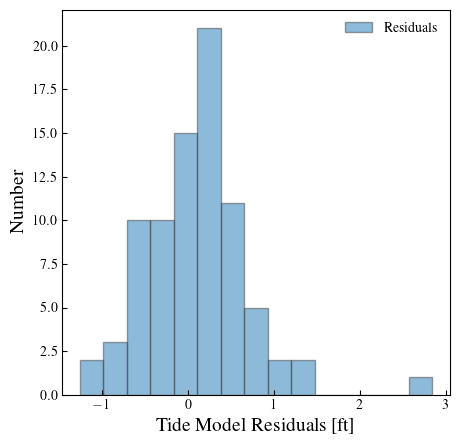

In [16]:
#create the figure and axes for a single plot
f,ax = plt.subplots(1,1,figsize=(5,5))

#change the font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

#plot the data
plt.hist(residuals_outlier,bins=15,alpha=0.5,edgecolor='0.25',label='Residuals')

#set the tickmarks inward
ax.xaxis.set_tick_params(direction='in')
ax.yaxis.set_tick_params(direction='in')


#increase the label font size
label_font_size = 14
ax.set_xlabel('Tide Model Residuals [ft]',fontsize=label_font_size)
ax.set_ylabel('Number',fontsize=label_font_size)

#add a legend
ax.legend(frameon=False)

#save the figure
plt.savefig('group_project_solution-outlier.pdf',bbox_inches="tight",pad_inches=0,facecolor='1')